In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score


In [2]:

iris = load_iris(as_frame=True)
wine = load_wine(as_frame=True)

df_iris = iris.frame
df_wine = wine.frame

df_iris.head(), df_wine.head()

(   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
 0                5.1               3.5                1.4               0.2   
 1                4.9               3.0                1.4               0.2   
 2                4.7               3.2                1.3               0.2   
 3                4.6               3.1                1.5               0.2   
 4                5.0               3.6                1.4               0.2   
 
    target  
 0       0  
 1       0  
 2       0  
 3       0  
 4       0  ,
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
 0    14.23        1.71  2.43               15.6      127.0           2.80   
 1    13.20        1.78  2.14               11.2      100.0           2.65   
 2    13.16        2.36  2.67               18.6      101.0           2.80   
 3    14.37        1.95  2.50               16.8      113.0           3.85   
 4    13.24        2.59  2.87               21.0 

In [3]:
X_i = df_iris.drop('target', axis=1)
y_i = df_iris['target']

X_i_tr, X_i_te, y_i_tr, y_i_te = train_test_split(X_i, y_i, test_size=0.2, random_state=42)

# Wine
X_w = df_wine.drop('target', axis=1)
y_w = df_wine['target']

X_w_tr, X_w_te, y_w_tr, y_w_te = train_test_split(X_w, y_w, test_size=0.2, random_state=42)


In [4]:
svm_lin = SVC(kernel='linear')
svm_lin.fit(X_i_tr, y_i_tr)
pred_lin = svm_lin.predict(X_i_te)

acc_lin = accuracy_score(y_i_te, pred_lin)
acc_lin, svm_lin.n_support_


(1.0, array([ 3, 11, 11], dtype=int32))

In [5]:



svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_i_tr, y_i_tr)
pred_rbf = svm_rbf.predict(X_i_te)

acc_rbf = accuracy_score(y_i_te, pred_rbf)
acc_rbf


1.0

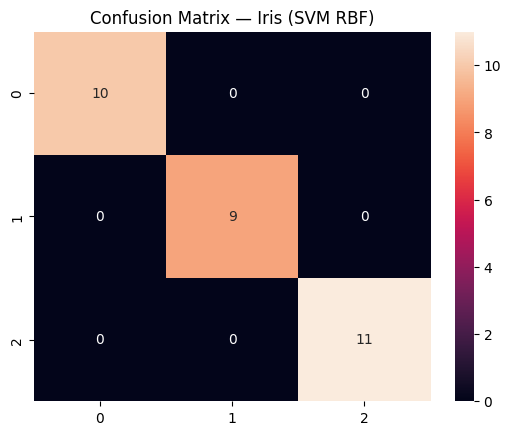

1.0

In [6]:


cm = confusion_matrix(y_i_te, pred_rbf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix — Iris (SVM RBF)")
plt.show()

f1_score(y_i_te, pred_rbf, average='macro')


In [7]:
log = LogisticRegression(max_iter=5000)
log.fit(X_i_tr, y_i_tr)
pred_log = log.predict(X_i_te)

accuracy_score(y_i_te, pred_log)

1.0

In [8]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_i_tr, y_i_tr)
pred_knn = knn.predict(X_i_te)

accuracy_score(y_i_te, pred_knn)

1.0

In [9]:
results = pd.DataFrame({
    'Model': ['SVM Linear', 'SVM RBF', 'Logistic Regression', 'k-NN'],
    'Accuracy': [
        accuracy_score(y_i_te, pred_lin),
        accuracy_score(y_i_te, pred_rbf),
        accuracy_score(y_i_te, pred_log),
        accuracy_score(y_i_te, pred_knn)
    ]
})
results

,Model,Accuracy
0,SVM Linear,1.0
1,SVM RBF,1.0
2,Logistic Regression,1.0
3,k-NN,1.0
